In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('../data/netflix_clean.csv')
print(df.shape)
df.head()

(8807, 18)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_num,duration_unit,primary_country,genres
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,90.0,min,United States,['Documentaries']
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,2.0,Season,South Africa,"['International TV Shows', 'TV Dramas', 'TV My..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,1.0,Season,Unknown,"['Crime TV Shows', 'International TV Shows', '..."
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,1.0,Season,Unknown,"['Docuseries', 'Reality TV']"
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,2.0,Season,India,"['International TV Shows', 'Romantic TV Shows'..."


C:\Users\Administrator\AppData\Local\Temp\ipykernel_12556\2110296113.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette=['#E50914', '#221F1F'])


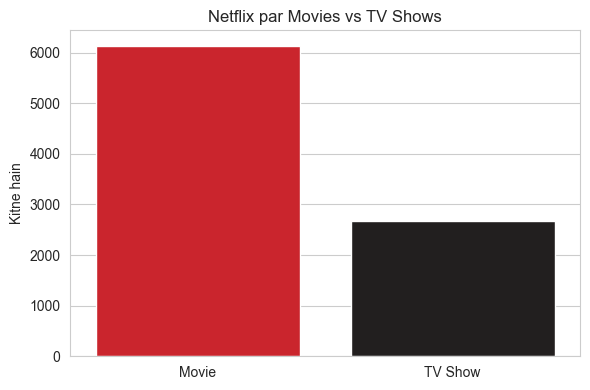

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Feesad:
type
Movie      69.6
TV Show    30.4
Name: proportion, dtype: float64


In [2]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', palette=['#E50914', '#221F1F'])
plt.title('Netflix par Movies vs TV Shows')
plt.xlabel('')
plt.ylabel('Kitne hain')
plt.tight_layout()
plt.savefig('../screenshots/01_type_distribution.png', dpi=150)
plt.show()

print(df['type'].value_counts())
print("\nFeesad:")
print(df['type'].value_counts(normalize=True).round(3) * 100)

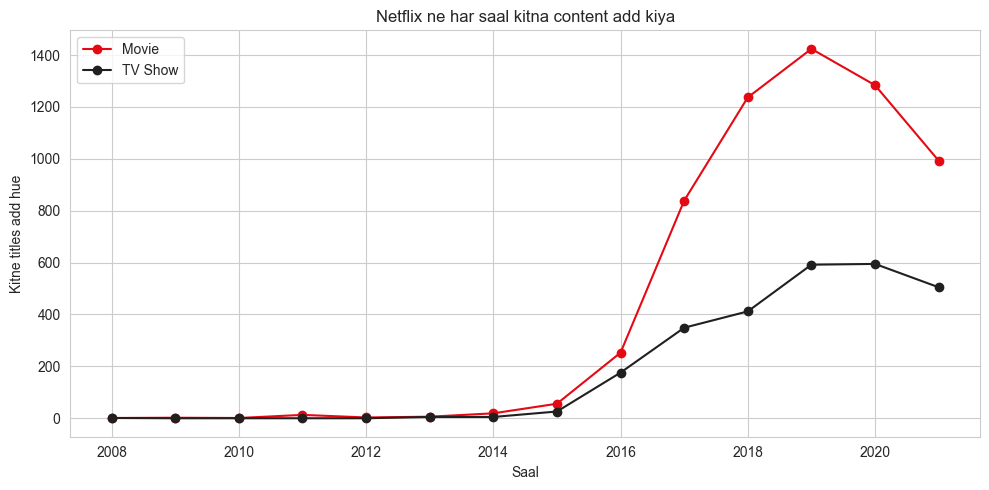

type        Movie  TV Show
year_added                
2012.0          3        0
2013.0          6        5
2014.0         19        5
2015.0         56       26
2016.0        253      176
2017.0        839      349
2018.0       1237      412
2019.0       1424      592
2020.0       1284      595
2021.0        993      505


In [3]:
plt.figure(figsize=(10, 5))

yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly.plot(kind='line', marker='o', color=['#E50914', '#221F1F'], ax=plt.gca())

plt.title('Netflix ne har saal kitna content add kiya')
plt.xlabel('Saal')
plt.ylabel('Kitne titles add hue')
plt.legend(title='')
plt.tight_layout()
plt.savefig('../screenshots/02_yearly_growth.png', dpi=150)
plt.show()

print(yearly.tail(10))

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12556\1175638481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')


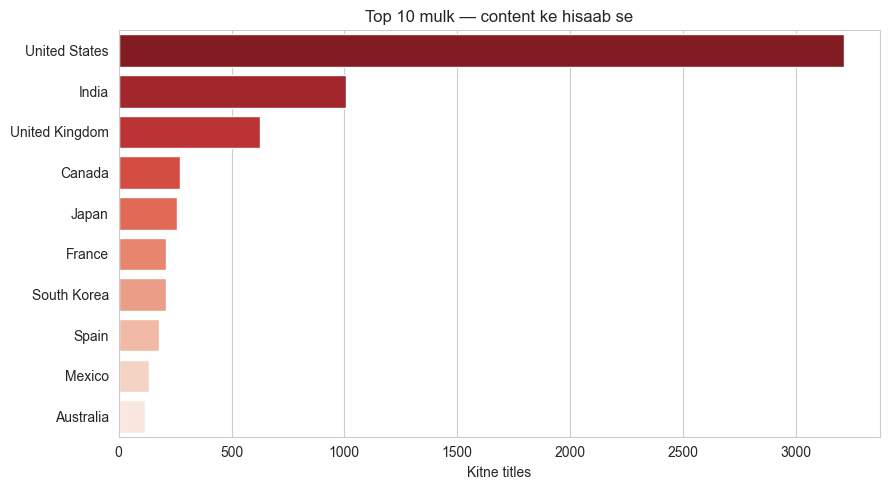

primary_country
United States     3211
India             1008
United Kingdom     628
Canada             271
Japan              259
France             212
South Korea        211
Spain              181
Mexico             134
Australia          117
Name: count, dtype: int64


In [4]:
plt.figure(figsize=(9, 5))

top_countries = df[df['primary_country'] != 'Unknown']['primary_country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')

plt.title('Top 10 mulk — content ke hisaab se')
plt.xlabel('Kitne titles')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../screenshots/03_top_countries.png', dpi=150)
plt.show()

print(top_countries)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12556\1715861878.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')


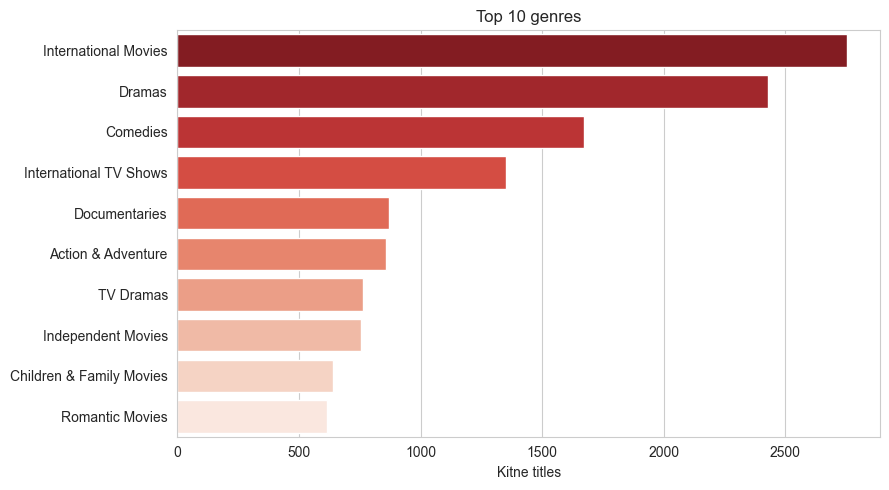

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [5]:
# Har genre ko alag row banao
genres_exploded = df['listed_in'].str.split(', ').explode()
top_genres = genres_exploded.value_counts().head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')

plt.title('Top 10 genres')
plt.xlabel('Kitne titles')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../screenshots/04_top_genres.png', dpi=150)
plt.show()

print(top_genres)

**Knowledge:** "International Movies" sab se upar hai (2752) — yani
Netflix ka sab se bara genre ghair-Amreeki content hai.

Ye pichle chart se mel khata hai: India, Japan, South Korea, Spain sab
top 10 mein hain. Netflix ki soch saaf hai — barhna hai to America se
bahar barho.

**Technical note:** ek title ke kai genres hote hain, is liye `explode()`
istemal kiya taake har genre alag gina jaye. Bina explode ke
"Dramas, Thrillers" khud ek genre ban jata, jo ghalat hota.

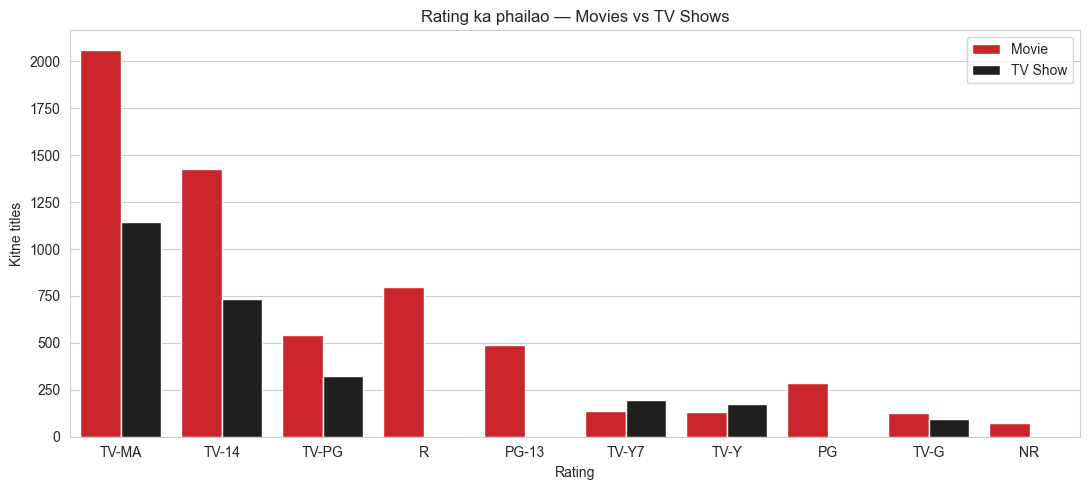

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(11, 5))

top_ratings = df[df['rating'] != 'Unknown']['rating'].value_counts().head(10).index
data = df[df['rating'].isin(top_ratings)]

sns.countplot(data=data, x='rating', hue='type',
              order=top_ratings, palette=['#E50914', '#221F1F'])

plt.title('Rating ka phailao — Movies vs TV Shows')
plt.xlabel('Rating')
plt.ylabel('Kitne titles')
plt.legend(title='')
plt.tight_layout()
plt.savefig('../screenshots/05_ratings.png', dpi=150)
plt.show()

print(df['rating'].value_counts().head(8))

**Got knoweldge:** TV-MA (adult ke liye) sab se zyada hai — 3207
titles, taqreeban 36%. TV-14 dusre number par.

Matlab Netflix ka main target **baray log hain, bachay nahi**.
Bachon ka content (TV-Y, TV-G) bohat kam hai.


## Task 2 — Summary

5 charts se 5 cheezen pata chalin:

1. **Movies zyada hain** — 70% movies, 30% TV shows. Movie ek dafa banti
   hai, TV show har season paisa maangta hai.

2. **2019 sab se bara saal tha** — 1424 movies add hui. Uske baad kami aayi
   kyunke Netflix ne doosron ka content khareedna kam kar diya aur apna
   banana shuru kar diya.

3. **India number 2 par hai** (1008 titles), UK se bhi aage. Netflix Indian
   market par bara focus kar raha hai.

4. **International Movies sab se bara genre hai** (2752) — Netflix ki growth
   America se bahar se aa rahi hai.

5. **TV-MA sab se common rating hai** (3207, ~36%) — matlab target audience
   adults hain. Kids ke content mein bara gap hai.

